In [1]:
from typing import List, TypedDict
import re

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from dotenv import load_dotenv

load_dotenv()

C:\Users\rajen\AppData\Local\Temp\ipykernel_7308\1606832313.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


True

In [2]:
llm = ChatOpenAI()
llm.invoke('hi')

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'text_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None, 'video_tokens': 0}, 'cost': 1.75e-05, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 1.75e-05, 'upstream_inference_prompt_cost': 4e-06, 'upstream_inference_completions_cost': 1.35e-05}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-3.5-turbo', 'system_fingerprint': None, 'id': 'gen-1790158087-esTQg9Syk25DV6jUNYRb', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0cdbc-a22a-7233-8397-ab8ed871e522-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={

In [5]:
docs = (
    PyPDFLoader("./documents/book1.pdf").load()
    + PyPDFLoader("./documents/book2.pdf").load()
    + PyPDFLoader("./documents/book3.pdf").load()
)

fontTools is required to fully parse the encoding of a CFF Type1 font in font dictionary {'/Subtype': '/Type1', '/FontDescriptor': IndirectObject(25, 0, 2439382305488), '/LastChar': 1, '/Widths': [833], '/BaseFont': '/NJBOIP+MathematicalPi-Three', '/FirstChar': 1, '/Encoding': IndirectObject(26, 0, 2439382305488), '/Type': '/Font'}, but is not installed. Consider installing fontTools if you encounter encoding problems.
fontTools is required to fully parse the encoding of a CFF Type1 font in font dictionary {'/Subtype': '/Type1', '/FontDescriptor': IndirectObject(743, 0, 2439382305488), '/LastChar': 2, '/Widths': [778, 778], '/BaseFont': '/NJDFHF+MSAM10', '/FirstChar': 1, '/Encoding': IndirectObject(744, 0, 2439382305488), '/Type': '/Font'}, but is not installed. Consider installing fontTools if you encounter encoding problems.
fontTools is required to fully parse the encoding of a CFF Type1 font in font dictionary {'/Subtype': '/Type1', '/FontDescriptor': IndirectObject(743, 0, 2439382

In [6]:
chunks = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200).split_documents(docs)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [7]:
embeddings = OpenAIEmbeddings()
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 4})

In [8]:
llm = ChatOpenAI()

In [9]:
class State(TypedDict):
    question: str
    docs: List[Document]

    strips: List[str]            # output of decomposition (sentence strips)
    kept_strips: List[str]       # after filtering (kept sentences)
    refined_context: str         # recomposed internal knowledge (joined kept_strips)

    answer: str

In [10]:
def retrieve(state: State) -> State:
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [11]:
# -----------------------------
# Sentence-level DECOMPOSER
# -----------------------------
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]


# -----------------------------
# FILTER (LLM judge)
# -----------------------------
class KeepOrDrop(BaseModel):
    keep: bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)


# -----------------------------
# REFINING (Decompose -> Filter -> Recompose)
# -----------------------------
def refine(state: State) -> State:

    q = state["question"]

    # Combine retrieved docs into one context string
    context = "\n\n".join(d.page_content for d in state["docs"]).strip()

    # 1) DECOMPOSITION: context -> sentence strips
    strips = decompose_to_sentences(context)

    # 2) FILTER: keep only relevant strips
    kept: List[str] = []
    
    for s in strips:
        if filter_chain.invoke({"question": q, "sentence": s}).keep:
            kept.append(s)

    # 3) RECOMPOSE: glue kept strips back together (internal knowledge)
    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }

c:\Users\rajen\Desktop\Corrective RAG\.venv\Lib\site-packages\langchain_openai\chat_models\base.py:2695: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [12]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
            "If the bullets are empty or insufficient, say: 'I don't know based on the provided books.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate(state: State) -> State:
    out = (answer_prompt | llm).invoke({"question": state["question"], "refined_context": state['refined_context']})
    return {"answer": out.content}

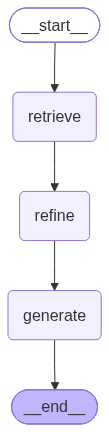

In [14]:
g = StateGraph(State)
g.add_node("retrieve", retrieve)
g.add_node("refine", refine)
g.add_node("generate", generate)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "refine")
g.add_edge("refine", "generate")
g.add_edge("generate", END)

app = g.compile()

app

In [15]:
res = app.invoke({
    "question": "Explain the bias–variance tradeoff",
    "docs": [],
    "strips": [],
    "kept_strips": [],
    "refined_context": "",
    "answer": ""
})
print(res["answer"])

- Generalization error is the sum of three distinct errors: bias, variance, and irreducible error
- Bias occurs due to incorrect assumptions made by the model, leading to underfitting
- Variance arises from the model's sensitivity to the training data, resulting in overfitting
- Models with higher degrees of freedom tend to have higher variance leading to overfitting
- Optimal model complexity minimizes the sum of squared bias and variance
- Regularization helps reduce variance but can increase bias if the regularization coefficient is too large


In [16]:
print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

to consider a frequentist viewpoint of the model complexity issue, known as thebias-
variance trade-off. Although we shall introduce this concept in the context of linear
basis function models, where it is easy to illustrate the ideas using simple examples,
the discussion has more general applicability.
In Section 1.5.5, when we discussed decision theory for regression problems,
we considered various loss functions each of which leads to a corresponding optimal
prediction once we are given the conditional distributionp(t|x). A popular choice is
****************************************************************************************************
10 This notion of bias is not to be confused with the bias term of linear models.
Figure 4-16. Learning curves for the polynomial model
One way to improve an overfitting model is to feed it more training
da
ta until the validation error reaches the training error.
The Bias/Variance Tradeoff
An importan
t theoretical result of statistics and Machi